## Tarea M33-AD – Alejandra
### Exploratory Data Analysis - Ventas de Videojuegos

Alejandra Cetina, 11/08/2026

Copia de actividad para demostrar el control de versiones

---
#### Preparación de Datos

In [ ]:
import pandas as pd
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt

pd.options.display.float_format = '{:.3f}'.format
os.chdir(r"C:\Users\alece\OneDrive\Escaneos\Documentos\Cursos\Análisis de Datos - EBAC")

# Se crea la carpeta 'figs' para guardar los gráficos (si no existe)
os.makedirs('figs', exist_ok=True)

df = pd.read_csv('vgsales.csv')

Exploración Básica

In [2]:
df.head(5)

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.00,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.00,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.00,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.00,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.00,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


In [3]:
df.tail(5)

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
16593,16596,Woody Woodpecker in Crazy Castle 5,GBA,2002.00,Platform,Kemco,0.01,0.00,0.00,0.00,0.01
16594,16597,Men in Black II: Alien Escape,GC,2003.00,Shooter,Infogrames,0.01,0.00,0.00,0.00,0.01
16595,16598,SCORE International Baja 1000: The Official Game,PS2,2008.00,Racing,Activision,0.00,0.00,0.00,0.00,0.01
16596,16599,Know How 2,DS,2010.00,Puzzle,7G//AMES,0.00,0.01,0.00,0.00,0.01
16597,16600,Spirits & Spells,GBA,2003.00,Platform,Wanadoo,0.01,0.00,0.00,0.00,0.01


In [4]:
df.sample(5)

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
5586,5588,Test Drive Unlimited,X360,2006.00,Racing,Atari,0.23,0.04,0.02,0.03,0.32
4301,4303,Top Spin,XB,2003.00,Sports,Microsoft Game Studios,0.36,0.08,0.00,0.02,0.46
4049,4051,Doom 3 BFG Edition,X360,2012.00,Shooter,Bethesda Softworks,0.28,0.17,0.00,0.04,0.49
13763,13765,One Piece: Burning Blood,XOne,2016.00,Fighting,Namco Bandai Games,0.03,0.01,0.00,0.00,0.04
14337,14340,Rampo,SAT,1995.00,Adventure,Sega,0.00,0.00,0.03,0.00,0.03


In [5]:
df.shape

(16598, 11)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16598 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16598 non-null  int64  
 1   Name          16598 non-null  object 
 2   Platform      16598 non-null  object 
 3   Year          16327 non-null  float64
 4   Genre         16598 non-null  object 
 5   Publisher     16540 non-null  object 
 6   NA_Sales      16598 non-null  float64
 7   EU_Sales      16598 non-null  float64
 8   JP_Sales      16598 non-null  float64
 9   Other_Sales   16598 non-null  float64
 10  Global_Sales  16598 non-null  float64
dtypes: float64(6), int64(1), object(4)
memory usage: 1.4+ MB


In [7]:
df.describe()

,Rank,Year,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
count,16598.00,16327.00,16598.00,16598.00,16598.00,16598.00,16598.00
mean,8300.61,2006.41,0.26,0.15,0.08,0.05,0.54
std,4791.85,5.83,0.82,0.51,0.31,0.19,1.56
min,1.00,1980.00,0.00,0.00,0.00,0.00,0.01
25%,4151.25,2003.00,0.00,0.00,0.00,0.00,0.06
50%,8300.50,2007.00,0.08,0.02,0.00,0.01,0.17
75%,12449.75,2010.00,0.24,0.11,0.04,0.04,0.47
max,16600.00,2020.00,41.49,29.02,10.22,10.57,82.74


In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Rank,16598.00,8300.61,4791.85,1.00,4151.25,8300.50,12449.75,16600.00
Year,16327.00,2006.41,5.83,1980.00,2003.00,2007.00,2010.00,2020.00
NA_Sales,16598.00,0.26,0.82,0.00,0.00,0.08,0.24,41.49
EU_Sales,16598.00,0.15,0.51,0.00,0.00,0.02,0.11,29.02
JP_Sales,16598.00,0.08,0.31,0.00,0.00,0.00,0.04,10.22
Other_Sales,16598.00,0.05,0.19,0.00,0.00,0.01,0.04,10.57
Global_Sales,16598.00,0.54,1.56,0.01,0.06,0.17,0.47,82.74


In [9]:
# Validación de columnas numéricas, para que el análisis funcione con todas
cols_num = df.select_dtypes(include=[np.number]).columns.tolist()
print('Columnas numéricas encontradas:')
print(cols_num)

Columnas numéricas encontradas:
['Rank', 'Year', 'NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales']


In [10]:
# Número de valores no únicos por columna
# Para ver la estructura interna de cada columna - qué tan variada es
df.nunique()

Rank            16598
Name            11493
Platform           31
Year               39
Genre              12
Publisher         578
NA_Sales          409
EU_Sales          305
JP_Sales          244
Other_Sales       157
Global_Sales      623
dtype: int64

In [11]:
# Se buscan valores nulos en todas las columnas del dataframe
print('Hay', df.isnull().sum().sum(), 'valores nulos en total')
df.isnull().sum()

Hay 329 valores nulos en total


Rank              0
Name              0
Platform          0
Year            271
Genre             0
Publisher        58
NA_Sales          0
EU_Sales          0
JP_Sales          0
Other_Sales       0
Global_Sales      0
dtype: int64

Se observa que las columnas `Year` (271 nulos) y `Publisher` (58 nulos) tienen datos faltantes. Como el análisis por año es central en este ejercicio, se genera un dataframe limpio (`df_clean`) sin nulos en `Year`, conservando el original (`df`) para los totales generales.

In [12]:
# Se genera un dataframe limpio para el análisis por año
df_clean = df.dropna(subset=['Year']).copy()
df_clean['Year'] = df_clean['Year'].astype(int)
print('Registros originales:', df.shape[0])
print('Registros con año válido:', df_clean.shape[0])

Registros originales: 16598
Registros con año válido: 16327


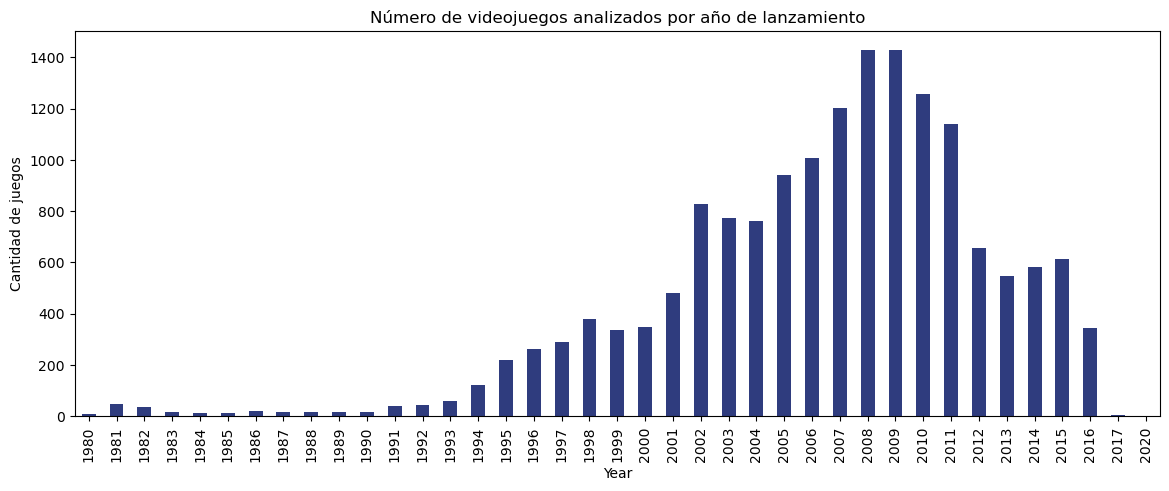

In [13]:
# Gráfico de cantidad de juegos lanzados por año, para revisar calidad del dato
df_clean.groupby('Year')['Year'].count().plot.bar(figsize=(14,5), color='#2F3C7E')
plt.title('Número de videojuegos analizados por año de lanzamiento')
plt.ylabel('Cantidad de juegos')
plt.savefig('figs/00_juegos_por_anio.png', dpi=150, bbox_inches='tight')
plt.show()

**Hallazgo (calidad de datos):** a partir de 2017 el número de registros cae drásticamente (solo 3 juegos en 2017 y 1 en 2020), lo cual indica que el dataset fue recolectado y quedó incompleto después de 2016. Por esta razón, para el análisis de **crecimiento de los últimos 4 años** se utilizará la ventana **2013-2016**, que es el periodo más reciente con datos completos y confiables.

---
### Totales

In [14]:
# 1) Total de videojuegos analizados
total_juegos = df.shape[0]
print('Total de videojuegos analizados:', total_juegos)

Total de videojuegos analizados: 16598


In [15]:
# 2) Total de géneros analizados
generos = df['Genre'].unique()
total_generos = df['Genre'].nunique()
print('Total de géneros analizados:', total_generos)
print(generos)

Total de géneros analizados: 12
['Sports' 'Platform' 'Racing' 'Role-Playing' 'Puzzle' 'Misc' 'Shooter'
 'Simulation' 'Action' 'Fighting' 'Adventure' 'Strategy']


In [16]:
# 3) Total de plataformas analizadas
plataformas = df['Platform'].unique()
total_plataformas = df['Platform'].nunique()
print('Total de plataformas analizadas:', total_plataformas)
print(plataformas)

Total de plataformas analizadas: 31
['Wii' 'NES' 'GB' 'DS' 'X360' 'PS3' 'PS2' 'SNES' 'GBA' '3DS' 'PS4' 'N64'
 'PS' 'XB' 'PC' '2600' 'PSP' 'XOne' 'GC' 'WiiU' 'GEN' 'DC' 'PSV' 'SAT'
 'SCD' 'WS' 'NG' 'TG16' '3DO' 'GG' 'PCFX']


---
### Ventas

#### 1) Total de ventas por año

In [17]:
regiones = ['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales']

# Agrupamiento general de ventas por año y región
ventas_por_anio = df_clean.groupby('Year')[regiones].sum()
ventas_por_anio

,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
Year,,,,,
1980,10.59,0.67,0.00,0.12,11.38
1981,33.40,1.96,0.00,0.32,35.77
1982,26.92,1.65,0.00,0.31,28.86
1983,7.76,0.80,8.10,0.14,16.79
1984,33.28,2.10,14.27,0.70,50.36
1985,33.73,4.74,14.56,0.92,53.94
1986,12.50,2.84,19.81,1.93,37.07
1987,8.46,1.41,11.63,0.20,21.74
1988,23.87,6.59,15.76,0.99,47.22


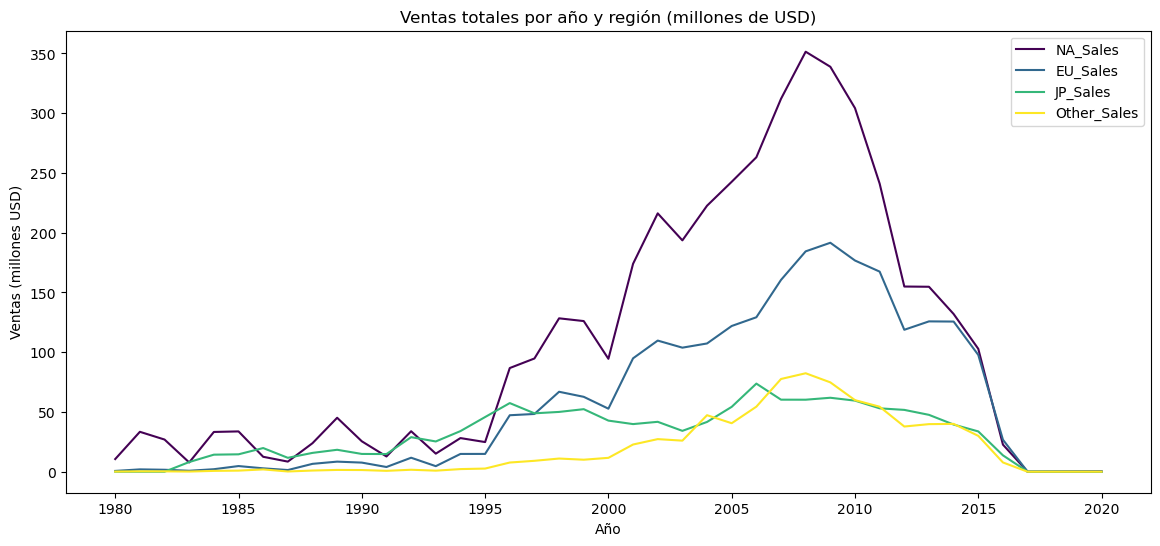

In [18]:
# Gráfico de ventas totales por año, desglosado por región
ventas_por_anio[['NA_Sales','EU_Sales','JP_Sales','Other_Sales']].plot(
    figsize=(14,6), colormap='viridis')
plt.title('Ventas totales por año y región (millones de USD)')
plt.ylabel('Ventas (millones USD)')
plt.xlabel('Año')
plt.savefig('figs/01_ventas_por_anio_region.png', dpi=150, bbox_inches='tight')
plt.show()

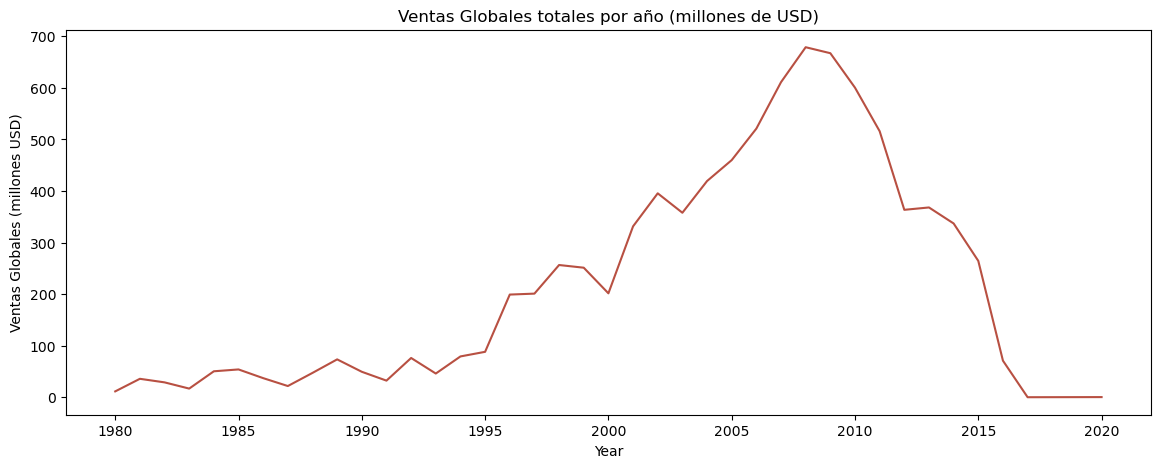

In [ ]:
# Ventas Globales por año
ventas_por_anio['Global_Sales'].plot.line(figsize=(14,5), color='#B85042')
plt.title('Ventas Globales totales por año (millones de USD)')
plt.ylabel('Ventas Globales (millones USD)')
plt.savefig('figs/02_ventas_globales_anio.png', dpi=150, bbox_inches='tight')
plt.show()

#### 2) Juegos más vendidos por año

In [20]:
# Función que identifica el juego más vendido de cada año, para una región dada
def juego_top_por_anio(data, columna_ventas):
    idx = data.groupby('Year')[columna_ventas].idxmax()
    top = data.loc[idx, ['Year', 'Name', 'Platform', 'Genre', columna_ventas]]
    return top.sort_values('Year').reset_index(drop=True)

# Juego más vendido por año - Global
top_global_anio = juego_top_por_anio(df_clean, 'Global_Sales')
top_global_anio.tail(15)

,Year,Name,Platform,Genre,Global_Sales
24,2004,Grand Theft Auto: San Andreas,PS2,Action,20.81
25,2005,Nintendogs,DS,Simulation,24.76
26,2006,Wii Sports,Wii,Sports,82.74
27,2007,Wii Fit,Wii,Sports,22.72
28,2008,Mario Kart Wii,Wii,Racing,35.82
29,2009,Wii Sports Resort,Wii,Sports,33.00
30,2010,Kinect Adventures!,X360,Misc,21.82
31,2011,Call of Duty: Modern Warfare 3,X360,Shooter,14.76
32,2012,Call of Duty: Black Ops II,PS3,Shooter,14.03
33,2013,Grand Theft Auto V,PS3,Action,21.40


In [21]:
# Juego más vendido por año en cada región
top_na_anio = juego_top_por_anio(df_clean, 'NA_Sales')
top_eu_anio = juego_top_por_anio(df_clean, 'EU_Sales')
top_jp_anio = juego_top_por_anio(df_clean, 'JP_Sales')
top_otros_anio = juego_top_por_anio(df_clean, 'Other_Sales')

print('Top NA (últimos 5 años con dato):')
print(top_na_anio.tail(5)[['Year','Name','Platform','NA_Sales']])
print('\nTop EU (últimos 5 años con dato):')
print(top_eu_anio.tail(5)[['Year','Name','Platform','EU_Sales']])
print('\nTop JP (últimos 5 años con dato):')
print(top_jp_anio.tail(5)[['Year','Name','Platform','JP_Sales']])
print('\nTop Otros (últimos 5 años con dato):')
print(top_otros_anio.tail(5)[['Year','Name','Platform','Other_Sales']])

Top NA (últimos 5 años con dato):
    Year                                              Name Platform  NA_Sales
34  2014         Pokemon Omega Ruby/Pokemon Alpha Sapphire      3DS      4.23
35  2015                         Call of Duty: Black Ops 3      PS4      5.77
36  2016                        Uncharted 4: A Thief's End      PS4      1.30
37  2017  Phantasy Star Online 2 Episode 4: Deluxe Package      PS4      0.00
38  2020                            Imagine: Makeup Artist       DS      0.27

Top EU (últimos 5 años con dato):
    Year                                              Name Platform  EU_Sales
34  2014                                Grand Theft Auto V      PS4      5.81
35  2015                                           FIFA 16      PS4      6.06
36  2016                                           FIFA 17      PS4      3.75
37  2017  Phantasy Star Online 2 Episode 4: Deluxe Package      PS4      0.00
38  2020                            Imagine: Makeup Artist       DS      

#### 3) Plataformas con más ingresos por año

In [22]:
# Tabla dinámica de ventas por plataforma y año (Global)
ventas_plat_anio = pd.pivot_table(df_clean, values='Global_Sales', index='Year',
                                   columns='Platform', aggfunc='sum').fillna(0)
ventas_plat_anio.tail(10)

Platform,2600,3DO,3DS,DC,DS,GB,GBA,GC,GEN,GG,...,SAT,SCD,SNES,TG16,WS,Wii,WiiU,X360,XB,XOne
Year,,,,,,,,,,,,,,,,,,,,,
2009,0.00,0.00,0.00,0.00,121.99,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,210.44,0.00,120.85,0.00,0.00
2010,0.00,0.00,0.00,0.00,87.98,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,131.80,0.00,171.05,0.00,0.00
2011,0.00,0.00,62.53,0.00,27.80,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,62.41,0.00,145.12,0.00,0.00
2012,0.00,0.00,51.14,0.00,11.64,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,22.77,17.84,100.88,0.00,0.00
2013,0.00,0.00,55.88,0.00,1.96,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,9.36,21.84,89.61,0.00,18.60
2014,0.00,0.00,43.14,0.00,0.02,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,4.44,22.51,36.42,0.00,52.43
2015,0.00,0.00,26.99,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,1.55,16.38,13.05,0.00,57.66
2016,0.00,0.00,6.60,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,3.29,0.83,0.00,12.37
2017,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00


In [23]:
# Función que identifica la plataforma con más ingresos por año, para una región dada
def plataforma_top_por_anio(data, columna_ventas):
    agrup = data.groupby(['Year','Platform'])[columna_ventas].sum().reset_index()
    idx = agrup.groupby('Year')[columna_ventas].idxmax()
    top = agrup.loc[idx].sort_values('Year').reset_index(drop=True)
    return top

plat_top_global = plataforma_top_por_anio(df_clean, 'Global_Sales')
plat_top_na = plataforma_top_por_anio(df_clean, 'NA_Sales')
plat_top_eu = plataforma_top_por_anio(df_clean, 'EU_Sales')
plat_top_jp = plataforma_top_por_anio(df_clean, 'JP_Sales')
plat_top_otros = plataforma_top_por_anio(df_clean, 'Other_Sales')

print('Plataforma líder por año (Global):')
plat_top_global.tail(10)

Plataforma líder por año (Global):


,Year,Platform,Global_Sales
29,2009,Wii,210.44
30,2010,X360,171.05
31,2011,PS3,159.37
32,2012,PS3,109.49
33,2013,PS3,117.39
34,2014,PS4,98.76
35,2015,PS4,115.30
36,2016,PS4,39.25
37,2017,PS4,0.03
38,2020,DS,0.29


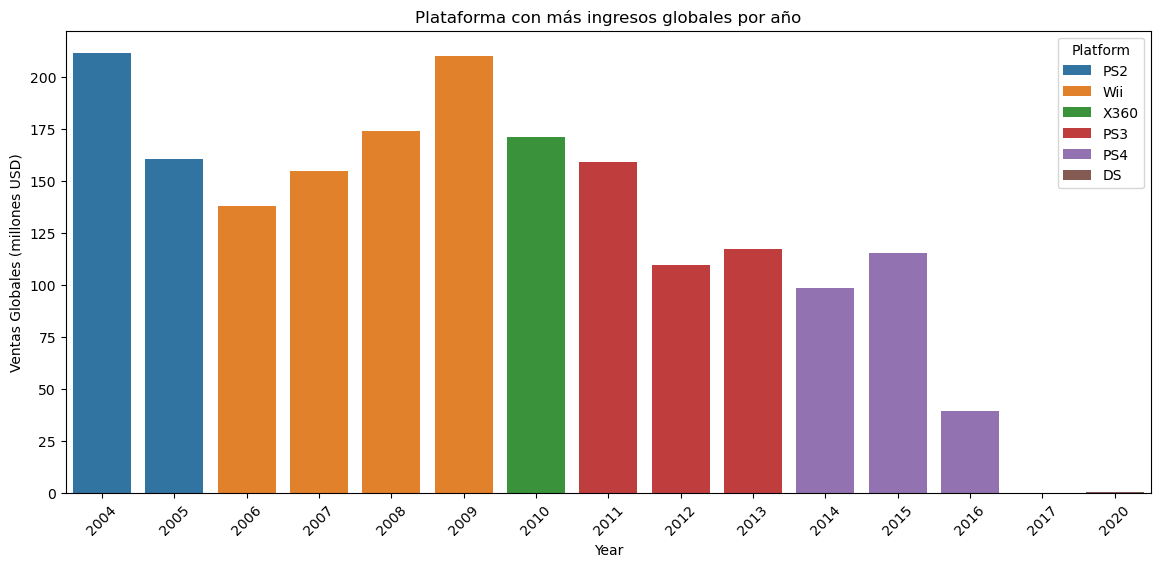

In [24]:
# Gráfico: plataforma líder en ingresos globales, por año
plt.figure(figsize=(14,6))
sns.barplot(data=plat_top_global.tail(15), x='Year', y='Global_Sales', hue='Platform', dodge=False)
plt.title('Plataforma con más ingresos globales por año')
plt.ylabel('Ventas Globales (millones USD)')
plt.xticks(rotation=45)
plt.savefig('figs/03_plataforma_top_anio.png', dpi=150, bbox_inches='tight')
plt.show()

#### 4) Comparación de ventas entre géneros, por año

In [25]:
# Tabla dinámica: ventas globales por género y año
ventas_genero_anio = pd.pivot_table(df_clean, values='Global_Sales', index='Year',
                                     columns='Genre', aggfunc='sum').fillna(0)
ventas_genero_anio.tail(10)

Genre,Action,Adventure,Fighting,Misc,Platform,Puzzle,Racing,Role-Playing,Shooter,Simulation,Sports,Strategy
Year,,,,,,,,,,,,
2009,139.36,20.68,32.15,76.94,41.09,20.31,34.19,47.90,69.89,33.71,138.52,12.56
2010,117.64,16.57,14.89,96.86,31.90,11.18,34.93,70.52,77.41,22.15,92.53,13.87
2011,118.96,15.98,22.68,56.08,28.11,5.11,35.01,53.37,99.36,15.28,56.99,9.06
2012,122.04,5.99,9.51,22.92,18.55,1.76,14.46,47.81,72.86,13.38,30.93,3.33
2013,125.22,6.61,7.21,25.65,25.12,0.99,13.04,44.92,62.80,8.67,41.55,6.33
2014,99.02,6.06,16.15,23.68,8.89,1.50,16.69,45.86,66.00,5.55,46.66,0.99
2015,70.70,8.03,7.78,11.69,6.05,0.70,7.92,36.44,66.15,5.62,41.54,1.82
2016,19.91,1.81,3.86,1.17,2.07,0.00,1.64,6.76,18.22,0.39,14.60,0.50
2017,0.01,0.00,0.00,0.00,0.00,0.00,0.00,0.04,0.00,0.00,0.00,0.00


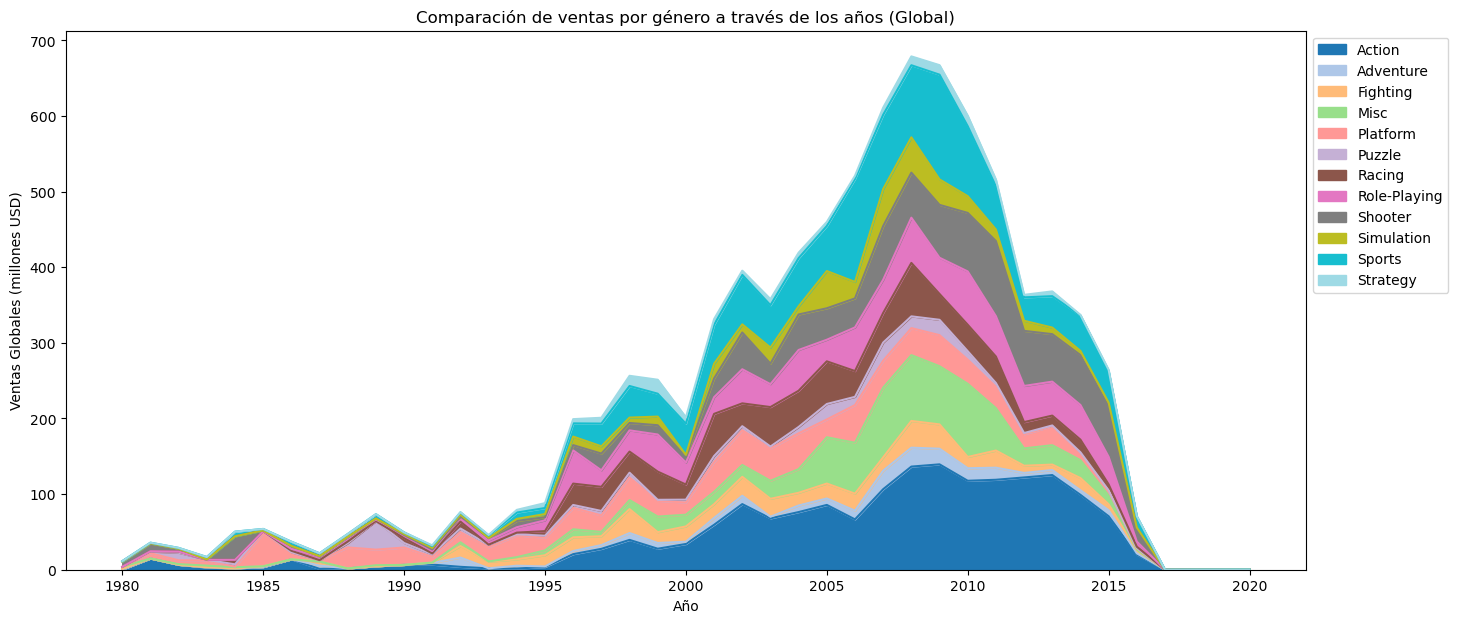

In [26]:
# Gráfico de comparación de ventas entre géneros por año (área apilada)
ventas_genero_anio.plot.area(figsize=(16,7), colormap='tab20')
plt.title('Comparación de ventas por género a través de los años (Global)')
plt.ylabel('Ventas Globales (millones USD)')
plt.xlabel('Año')
plt.legend(loc='upper left', bbox_to_anchor=(1,1))
plt.savefig('figs/04_ventas_genero_anio.png', dpi=150, bbox_inches='tight')
plt.show()

---
### Insights - Gráficos Adicionales

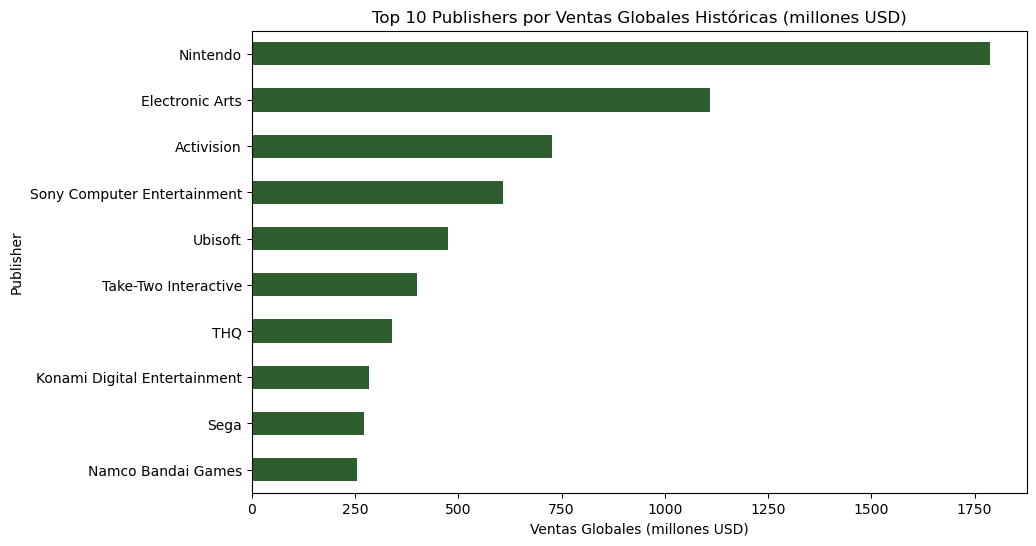

In [27]:
# Insight 1: Top 10 publishers (empresas) con más ventas globales históricas
top_publishers = df.groupby('Publisher')['Global_Sales'].sum().sort_values(ascending=False).head(10)
top_publishers.iloc[::-1].plot.barh(figsize=(10,6), color='#2C5F2D')
plt.title('Top 10 Publishers por Ventas Globales Históricas (millones USD)')
plt.xlabel('Ventas Globales (millones USD)')
plt.savefig('figs/05_top_publishers.png', dpi=150, bbox_inches='tight')
plt.show()

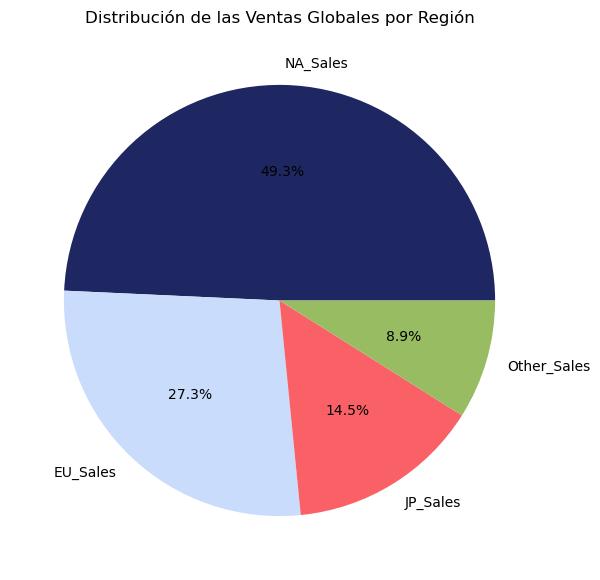

In [28]:
# Insight 2: Distribución de las ventas globales por región
ventas_region_total = df[['NA_Sales','EU_Sales','JP_Sales','Other_Sales']].sum()
ventas_region_total.plot.pie(figsize=(7,7), autopct='%1.1f%%',
                              colors=['#1E2761','#CADCFC','#F96167','#97BC62'])
plt.title('Distribución de las Ventas Globales por Región')
plt.ylabel('')
plt.savefig('figs/06_distribucion_region.png', dpi=150, bbox_inches='tight')
plt.show()

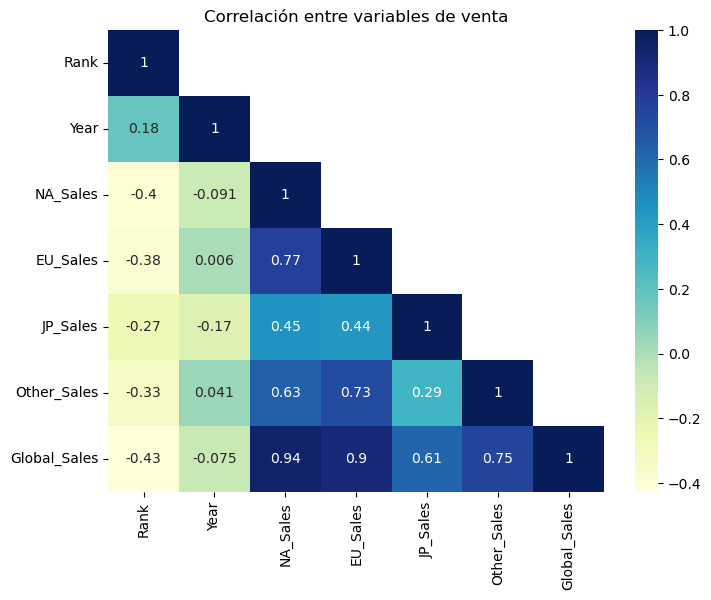

In [29]:
# Correlación entre las variables de venta
plt.figure(figsize=(8,6))
corr_df = df.corr(method='pearson', numeric_only=True)
df_lt = corr_df.where(np.tril(np.ones(corr_df.shape)).astype(bool))
sns.heatmap(df_lt, cmap='YlGnBu', annot=True)
plt.title('Correlación entre variables de venta')
plt.savefig('figs/07_correlacion.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Análisis de Crecimiento - Últimos 4 Años (2013-2016)

Como se identificó en la sección de calidad de datos, se utiliza la ventana **2013-2016** como los "últimos 4 años" con información completa y confiable.

In [30]:
# Se filtra el dataframe a los últimos 4 años con datos confiables
df_recientes = df_clean[df_clean['Year'].between(2013, 2016)].copy()
print('Registros en la ventana 2013-2016:', df_recientes.shape[0])
df_recientes['Year'].unique()

Registros en la ventana 2013-2016: 2086


array([2013, 2015, 2014, 2016])

#### 1) Género con mayor y menor crecimiento

In [31]:
# Tabla año x género con ventas globales
genero_anio = pd.pivot_table(df_recientes, values='Global_Sales', index='Year',
                              columns='Genre', aggfunc='sum').fillna(0)

# Se calcula el % de cambio año contra año, por género
genero_pct = genero_anio.pct_change()
genero_pct

Genre,Action,Adventure,Fighting,Misc,Platform,Puzzle,Racing,Role-Playing,Shooter,Simulation,Sports,Strategy
Year,,,,,,,,,,,,
2013,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2014,-0.21,-0.08,1.24,-0.08,-0.65,0.52,0.28,0.02,0.05,-0.36,0.12,-0.84
2015,-0.29,0.33,-0.52,-0.51,-0.32,-0.53,-0.53,-0.21,0.00,0.01,-0.11,0.84
2016,-0.72,-0.77,-0.50,-0.90,-0.66,-1.00,-0.79,-0.81,-0.72,-0.93,-0.65,-0.73


In [32]:
# Crecimiento promedio por género, ordenado de mayor a menor
crecimiento_genero = genero_pct.mean().sort_values(ascending=False)
crecimiento_genero

Genre
Fighting        0.07
Adventure      -0.18
Sports         -0.21
Shooter        -0.22
Strategy       -0.24
Role-Playing   -0.33
Puzzle         -0.34
Racing         -0.35
Action         -0.40
Simulation     -0.43
Misc           -0.49
Platform       -0.54
dtype: float64

In [33]:
print('Género con MAYOR crecimiento promedio:', crecimiento_genero.idxmax(),
      f'({crecimiento_genero.max()*100:.1f}%)')
print('Género con MENOR crecimiento promedio:', crecimiento_genero.idxmin(),
      f'({crecimiento_genero.min()*100:.1f}%)')

Género con MAYOR crecimiento promedio: Fighting (7.3%)
Género con MENOR crecimiento promedio: Platform (-54.1%)


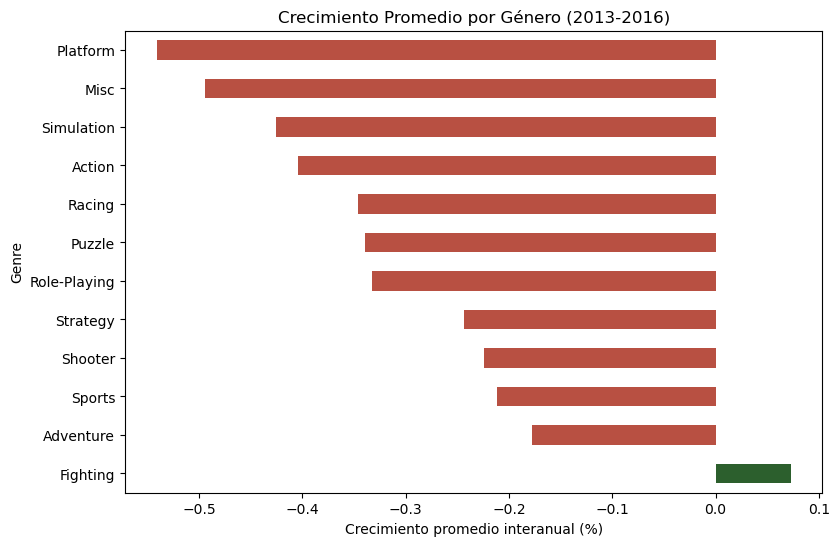

In [34]:
crecimiento_genero.plot.barh(figsize=(9,6), color=(crecimiento_genero>0).map({True:'#2C5F2D', False:'#B85042'}))
plt.title('Crecimiento Promedio por Género (2013-2016)')
plt.xlabel('Crecimiento promedio interanual (%)')
plt.savefig('figs/08_crecimiento_genero.png', dpi=150, bbox_inches='tight')
plt.show()

#### 2) Plataforma con mayor y menor crecimiento

In [35]:
# Tabla año x plataforma con ventas globales
plataforma_anio = pd.pivot_table(df_recientes, values='Global_Sales', index='Year',
                                  columns='Platform', aggfunc='sum').fillna(0)

# Se calcula el % de cambio año contra año, por plataforma
plataforma_pct = plataforma_anio.pct_change()
crecimiento_plataforma = plataforma_pct.mean().sort_values(ascending=False)
crecimiento_plataforma

Platform
PS4     0.83
XOne    0.38
PSV    -0.29
PC     -0.34
WiiU   -0.35
3DS    -0.45
PS3    -0.69
X360   -0.72
Wii    -0.73
PSP    -0.81
DS     -0.99
dtype: float64

In [36]:
print('Plataforma con MAYOR crecimiento promedio:', crecimiento_plataforma.idxmax(),
      f'({crecimiento_plataforma.max()*100:.1f}%)')
print('Plataforma con MENOR crecimiento promedio:', crecimiento_plataforma.idxmin(),
      f'({crecimiento_plataforma.min()*100:.1f}%)')

Plataforma con MAYOR crecimiento promedio: PS4 (83.2%)
Plataforma con MENOR crecimiento promedio: DS (-99.5%)


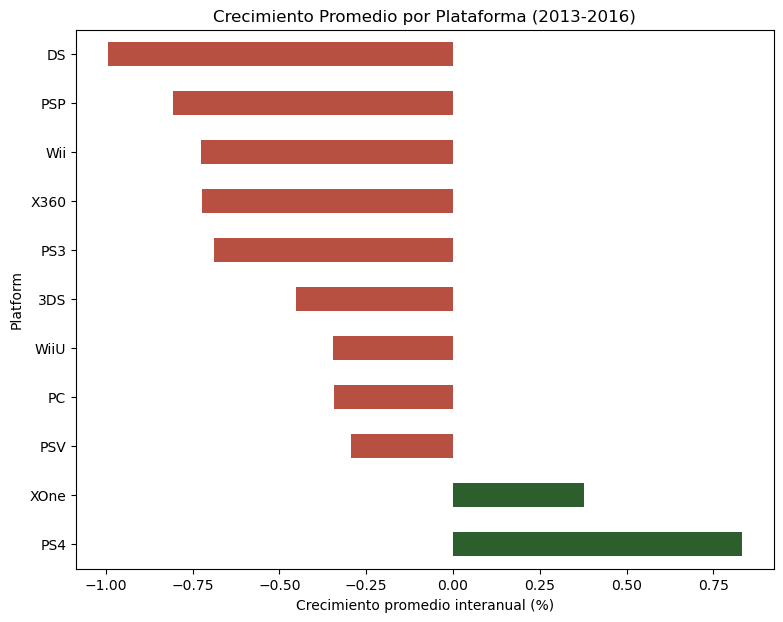

In [37]:
crecimiento_plataforma.plot.barh(figsize=(9,7), color=(crecimiento_plataforma>0).map({True:'#2C5F2D', False:'#B85042'}))
plt.title('Crecimiento Promedio por Plataforma (2013-2016)')
plt.xlabel('Crecimiento promedio interanual (%)')
plt.savefig('figs/09_crecimiento_plataforma.png', dpi=150, bbox_inches='tight')
plt.show()

#### 3) Videojuego con mayor y menor crecimiento

Como cada fila del dataset representa la venta acumulada (histórica) de un juego en una plataforma, el crecimiento de un videojuego solo puede calcularse para franquicias con **relanzamientos o nuevas entregas en más de un año** dentro de la ventana analizada (por ejemplo, secuelas anuales). Se agrupan las ventas por nombre y año, y se conservan solo los títulos presentes en 2 o más años.

In [38]:
# Ventas por juego y año
juego_anio = df_recientes.groupby(['Name','Year'])['Global_Sales'].sum().reset_index()
juego_pivot = juego_anio.pivot(index='Year', columns='Name', values='Global_Sales')

# Solo se consideran juegos presentes en 2 o más años (franquicias/relanzamientos)
apariciones = juego_pivot.notna().sum()
juegos_multi_anio = apariciones[apariciones >= 2].index
print('Juegos/franquicias con presencia en 2+ años:', len(juegos_multi_anio))

juego_pivot_multi = juego_pivot[juegos_multi_anio].fillna(0)
juego_pct = juego_pivot_multi.pct_change()
crecimiento_juego = juego_pct.mean().replace([np.inf, -np.inf], np.nan).dropna().sort_values(ascending=False)
crecimiento_juego

Juegos/franquicias con presencia en 2+ años: 47


Name
The Walking Dead: Season One                                 0.69
Warriors Orochi 3                                            0.36
Dungeon Travelers 2: The Royal Library & The Monster Seal    0.12
One Piece: Unlimited World Red                              -0.29
Metro: Last Light                                           -0.50
Dynasty Warriors 8: Xtreme Legends                          -0.52
Rayman Legends                                              -0.57
The Last of Us                                              -0.62
Diablo III                                                  -0.66
Final Fantasy XIV: A Realm Reborn                           -0.68
Tomb Raider (2013)                                          -0.77
Dragon Quest X                                              -0.79
Rocksmith 2014                                              -0.80
BlazBlue: Chrono Phantasma                                  -0.81
Akiba's Trip: Undead & Undressed                            -0.83
Grand

In [39]:
print('Videojuego con MAYOR crecimiento promedio:', crecimiento_juego.idxmax(),
      f'({crecimiento_juego.max()*100:.1f}%)')
print('Videojuego con MENOR crecimiento promedio:', crecimiento_juego.idxmin(),
      f'({crecimiento_juego.min()*100:.1f}%)')

Videojuego con MAYOR crecimiento promedio: The Walking Dead: Season One (69.4%)
Videojuego con MENOR crecimiento promedio: Nobunaga no Yabou: Souzou (-84.2%)


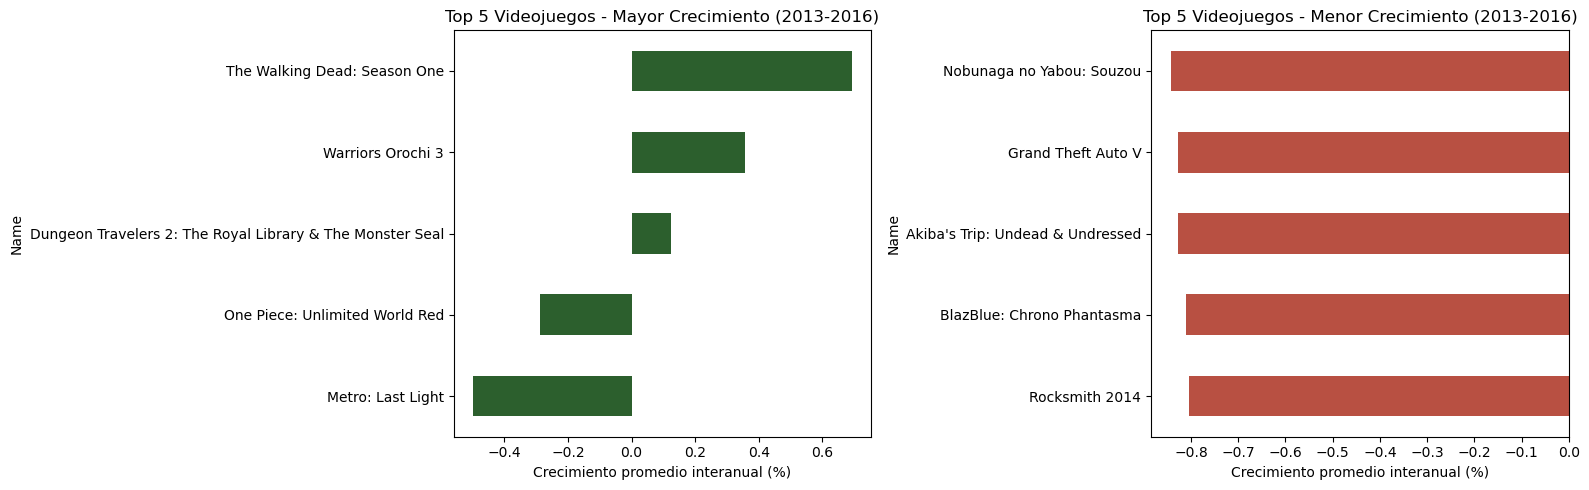

In [40]:
# Top 5 mayor y menor crecimiento
top5_mayor = crecimiento_juego.head(5)
top5_menor = crecimiento_juego.tail(5)

fig, axes = plt.subplots(1, 2, figsize=(16,5))
top5_mayor.iloc[::-1].plot.barh(ax=axes[0], color='#2C5F2D')
axes[0].set_title('Top 5 Videojuegos - Mayor Crecimiento (2013-2016)')
axes[0].set_xlabel('Crecimiento promedio interanual (%)')

top5_menor.plot.barh(ax=axes[1], color='#B85042')
axes[1].set_title('Top 5 Videojuegos - Menor Crecimiento (2013-2016)')
axes[1].set_xlabel('Crecimiento promedio interanual (%)')

plt.tight_layout()
plt.savefig('figs/10_crecimiento_juego.png', dpi=150, bbox_inches='tight')
plt.show()

---
### Oportunidades de Mercado

#### Oportunidad 1: Géneros con mayor venta promedio por título

Un género con pocas unidades vendidas en total, pero alta venta *promedio por título*, indica **alta demanda concentrada**

In [41]:
oportunidad_genero = df_recientes.groupby('Genre').agg(
    Titulos=('Name','count'),
    Venta_Promedio_Titulo=('Global_Sales','mean'),
    Venta_Total=('Global_Sales','sum')
).sort_values('Venta_Promedio_Titulo', ascending=False)
oportunidad_genero

,Titulos,Venta_Promedio_Titulo,Venta_Total
Genre,,,
Shooter,172,1.24,213.17
Sports,208,0.69,144.35
Platform,71,0.59,42.13
Racing,82,0.48,39.29
Role-Playing,280,0.48,133.98
Fighting,78,0.45,35.00
Action,708,0.44,314.85
Misc,140,0.44,62.19
Simulation,53,0.38,20.23


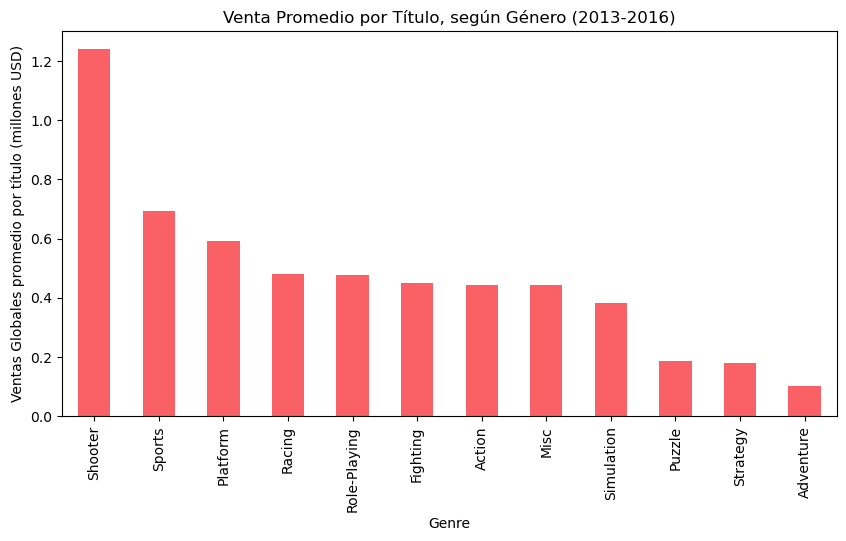

In [42]:
oportunidad_genero['Venta_Promedio_Titulo'].plot.bar(figsize=(10,5), color='#F96167')
plt.title('Venta Promedio por Título, según Género (2013-2016)')
plt.ylabel('Ventas Globales promedio por título (millones USD)')
plt.savefig('figs/11_oportunidad_genero.png', dpi=150, bbox_inches='tight')
plt.show()

#### Oportunidad 2: Plataformas nicho con alta venta promedio por título

Se buscan plataformas con **pocos títulos** pero **alta venta promedio por título**

In [43]:
oportunidad_plataforma = df_recientes.groupby('Platform').agg(
    Titulos=('Name','count'),
    Venta_Promedio_Titulo=('Global_Sales','mean'),
    Venta_Total=('Global_Sales','sum')
).sort_values('Venta_Promedio_Titulo', ascending=False)
oportunidad_plataforma

,Titulos,Venta_Promedio_Titulo,Venta_Total
Platform,,,
PS4,335,0.83,278.07
X360,188,0.74,139.91
Wii,22,0.70,15.35
XOne,213,0.66,141.06
WiiU,111,0.58,64.02
PS3,341,0.55,189.16
3DS,291,0.46,132.61
PC,170,0.22,36.89
DS,10,0.20,1.98


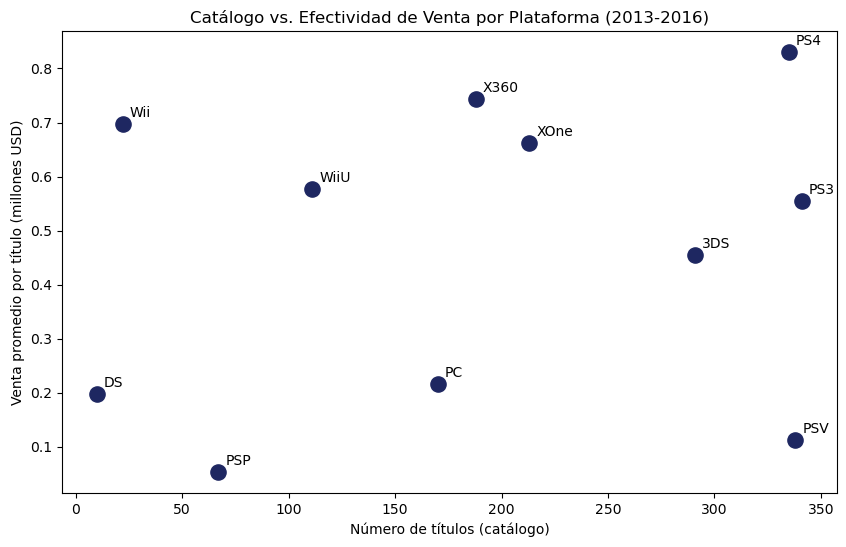

In [44]:
fig, ax = plt.subplots(figsize=(10,6))
scatter = ax.scatter(oportunidad_plataforma['Titulos'], oportunidad_plataforma['Venta_Promedio_Titulo'],
                      s=120, c='#1E2761')
for plataforma, fila in oportunidad_plataforma.iterrows():
    ax.annotate(plataforma, (fila['Titulos'], fila['Venta_Promedio_Titulo']),
                textcoords='offset points', xytext=(5,5))
ax.set_xlabel('Número de títulos (catálogo)')
ax.set_ylabel('Venta promedio por título (millones USD)')
ax.set_title('Catálogo vs. Efectividad de Venta por Plataforma (2013-2016)')
plt.savefig('figs/12_oportunidad_plataforma.png', dpi=150, bbox_inches='tight')
plt.show()

---
### Conclusiones

- El mercado de videojuegos está fuertemente concentrado en pocos géneros (Action, Sports, Shooter) y pocas plataformas dominantes en cada generación de consolas.
- En la ventana 2013-2016, **PS4** mostró el mayor crecimiento (impulsado por el inicio de la generación de consolas), mientras que plataformas de generación anterior como **DS** y **PSP** muestran el mayor declive, algo natural en su ciclo de vida.
- Géneros como **Shooter** presentan la mayor venta promedio por título, y plataformas de nicho como **Wii** muestran alta efectividad de venta con catálogo reducido — ambas son señales de oportunidad para una nueva plataforma: priorizar géneros de alta demanda por título y aprovechar ventanas de catálogo poco saturadas.
- Para una nueva plataforma, la recomendación es enfocar el catálogo de lanzamiento en géneros de alta venta promedio (Shooter, Sports) y negociar exclusivas con franquicias de crecimiento probado.